In [ ]:
import pandas as pd
df = pd.read_csv('df_final.csv')
df.head()

# 보수적 기대효과(발표 내용)

=== 3번 군집(남부) 1~2월 체리피킹 가맹점 분석 ===
               TOTAL_SPEND  AVG_TICKET_SIZE  TXN_COUNT
MERCHANT_NAME                                         
NO ENTITY       1850883.55        13.015784     142203
MCDONALDS       1401918.60        11.776079     119048
CHICK-FIL-A      615987.34        17.604668      34990
STARBUCKS        577266.37        13.764429      41939
TACO BELL        417708.64        15.072660      27713
WENDYS           346809.88        13.844706      25050
DOMINOS          336604.52        28.671595      11740
BURGER KING      291409.90        13.618558      21398
CHIPOTLE         280710.56        18.751540      14970
DUNKIN DONUTS    249544.33         9.440993      26432


=== 군집별 LTV 기대효과 요약 ===
    CLUSTER_K4     REGION  AVG_LTV_BEFORE  AVG_LTV_AFTER  GROWTH_RATE(%)
0            0    Midwest      227.100720     317.924078       39.992546
1            0  Northeast      256.617517     359.192619       39.971980
2            0      South      253.697876     355.127975    

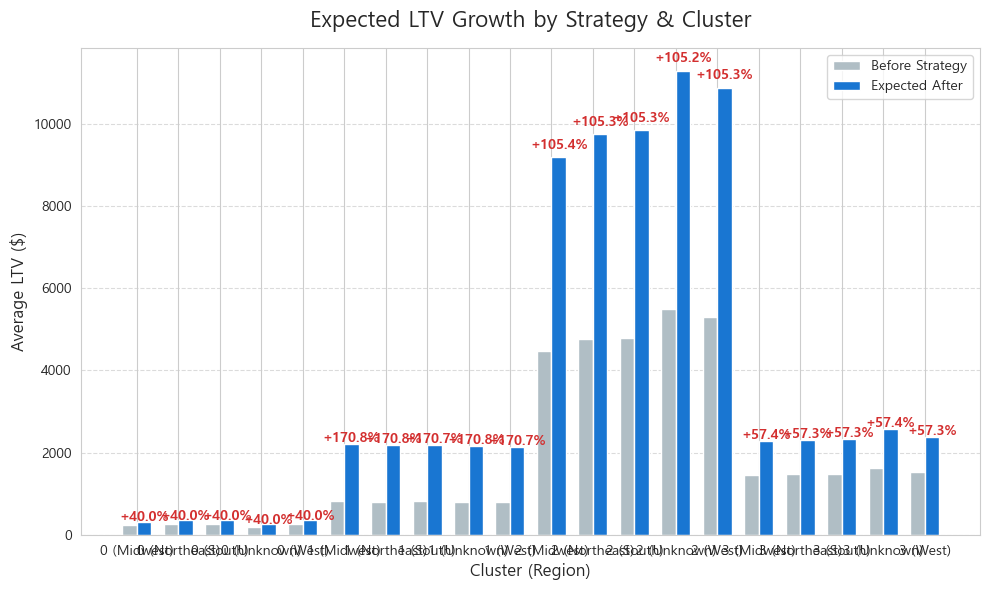

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시간 데이터 변환 (1~2월 필터링을 위해)
df['TRANSACTION_DATE'] = pd.to_datetime(df['TRANSACTION_DATE'])

# ---------------------------------------------------------
# 1. [남부 특화] 3번 군집 1~2월 체리피킹 가맹점 Top 10 분석
# ---------------------------------------------------------
print("=== 3번 군집(남부) 1~2월 체리피킹 가맹점 분석 ===")

# 3번 군집 & 1~2월 데이터 필터링
south_jan_feb = df[
    (df['CLUSTER_K4'] == 3) & 
    (df['TRANSACTION_DATE'].dt.month.isin([1, 2]))
]

# 가맹점별 총 결제액, 평균 객단가, 결제 건수 집계
cherry_picking_merchants = south_jan_feb.groupby('MERCHANT_NAME').agg(
    TOTAL_SPEND=('GROSS_TRANSACTION_AMOUNT', 'sum'),
    AVG_TICKET_SIZE=('GROSS_TRANSACTION_AMOUNT', 'mean'),
    TXN_COUNT=('TRANSACTION_ID', 'count')
).sort_values(by='TOTAL_SPEND', ascending=False).head(10)

print(cherry_picking_merchants)
print("\n")


# ---------------------------------------------------------
# 2. 전 군집 전략 실행 전후 LTV 시뮬레이션
# ---------------------------------------------------------
# 트랜잭션 단위 df를 유저(ACCOUNT_ID) 단위로 중복 제거하여 고객 풀 생성
customer_cols = [
    'ACCOUNT_ID', 'REGION', 'CLUSTER_K4', 
    'CARD_HOLDER_AVERAGE_LTM_SPEND', 'CARD_HOLDER_VINTAGE', 'CARD_HOLDER_TOTAL_SPEND'
]
customer_df = df[customer_cols].drop_duplicates(subset=['ACCOUNT_ID']).copy()

# 심화 LTV 계산 함수 정의
def calculate_ltv(ltm_spend, vintage, total_spend):
    # 0 나누기 방지를 위한 최소 유지기간 처리 (0개월인 경우 0.1로 처리)
    vintage_safe = np.where(vintage <= 0, 0.1, vintage)
    
    # 기본 LTV (수수료율 2%)
    base_ltv = ltm_spend * vintage_safe * 0.02
    
    # 최신성 지수
    avg_yearly_spend = np.where(total_spend == 0, ltm_spend, total_spend / vintage_safe)
    recency_multiplier = np.where(avg_yearly_spend == 0, 1, ltm_spend / avg_yearly_spend)
    
    return base_ltv * recency_multiplier

# 전략 실행 전 (Before) LTV 산출
customer_df['LTV_BEFORE'] = calculate_ltv(
    customer_df['CARD_HOLDER_AVERAGE_LTM_SPEND'],
    customer_df['CARD_HOLDER_VINTAGE'],
    customer_df['CARD_HOLDER_TOTAL_SPEND']
)

# 군집별 전략 기대효과 가중치 매핑 
# 포맷: {군집번호: (LTM_SPEND 상승배수, VINTAGE 상승배수)}
assumptions = {
    0: (1.15, 1.03), # 서부 (스벅 제휴)
    1: (1.10, 1.50), # 중서부 (학생증 연계, 락인)
    2: (1.25, 1.15), # 동북부 (VVIP 연회비, 구독)
    3: (1.20, 1.05)  # 남부 (축제 팔찌 펌핑)
}

# 가중치 적용을 위한 매핑
customer_df['LTM_MULT'] = customer_df['CLUSTER_K4'].map(lambda x: assumptions[x][0])
customer_df['VINTAGE_MULT'] = customer_df['CLUSTER_K4'].map(lambda x: assumptions[x][1])

# 전략 적용 후 (After) 예상 수치 계산
customer_df['EXPECTED_LTM_SPEND'] = customer_df['CARD_HOLDER_AVERAGE_LTM_SPEND'] * customer_df['LTM_MULT']
customer_df['EXPECTED_VINTAGE'] = customer_df['CARD_HOLDER_VINTAGE'] * customer_df['VINTAGE_MULT']
customer_df['EXPECTED_TOTAL_SPEND'] = customer_df['CARD_HOLDER_TOTAL_SPEND'] + (customer_df['EXPECTED_LTM_SPEND'] - customer_df['CARD_HOLDER_AVERAGE_LTM_SPEND'])

# 전략 실행 후 (After) 예상 LTV 산출
customer_df['LTV_AFTER'] = calculate_ltv(
    customer_df['EXPECTED_LTM_SPEND'],
    customer_df['EXPECTED_VINTAGE'],
    customer_df['EXPECTED_TOTAL_SPEND']
)

# 군집별 LTV 요약
ltv_summary = customer_df.groupby(['CLUSTER_K4', 'REGION']).agg(
    AVG_LTV_BEFORE=('LTV_BEFORE', 'mean'),
    AVG_LTV_AFTER=('LTV_AFTER', 'mean')
).reset_index()

ltv_summary['GROWTH_RATE(%)'] = ((ltv_summary['AVG_LTV_AFTER'] - ltv_summary['AVG_LTV_BEFORE']) / ltv_summary['AVG_LTV_BEFORE']) * 100

print("=== 군집별 LTV 기대효과 요약 ===")
print(ltv_summary)


# ---------------------------------------------------------
# 3. 결과 시각화 (Before & After 막대 그래프)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
x = np.arange(len(ltv_summary['REGION']))
width = 0.35

plt.bar(x - width/2, ltv_summary['AVG_LTV_BEFORE'], width, label='Before Strategy', color='#B0BEC5')
plt.bar(x + width/2, ltv_summary['AVG_LTV_AFTER'], width, label='Expected After', color='#1976D2')

plt.title('Expected LTV Growth by Strategy & Cluster', fontsize=16, pad=15)
plt.xlabel('Cluster (Region)', fontsize=12)
plt.ylabel('Average LTV ($)', fontsize=12)
plt.xticks(x, [f"{row['CLUSTER_K4']} ({row['REGION']})" for _, row in ltv_summary.iterrows()])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 증가율(%) 텍스트 표시
for i, row in ltv_summary.iterrows():
    plt.text(i + width/2, row['AVG_LTV_AFTER'] + (row['AVG_LTV_AFTER']*0.02), 
             f"+{row['GROWTH_RATE(%)']:.1f}%", ha='center', fontweight='bold', color='#D32F2F')

plt.tight_layout()
plt.show()

=== 타겟 지역 필터링 완료 요약 ===
   CLUSTER_K4     REGION  AVG_LTV_BEFORE  AVG_LTV_AFTER  GROWTH_RATE(%)
0           0       West      249.335297     349.023907       39.981748
1           1    Midwest      819.217797    2218.410172      170.796140
2           2  Northeast     4752.290593    9754.975608      105.268921
3           3      South     1480.374721    2328.636219       57.300458


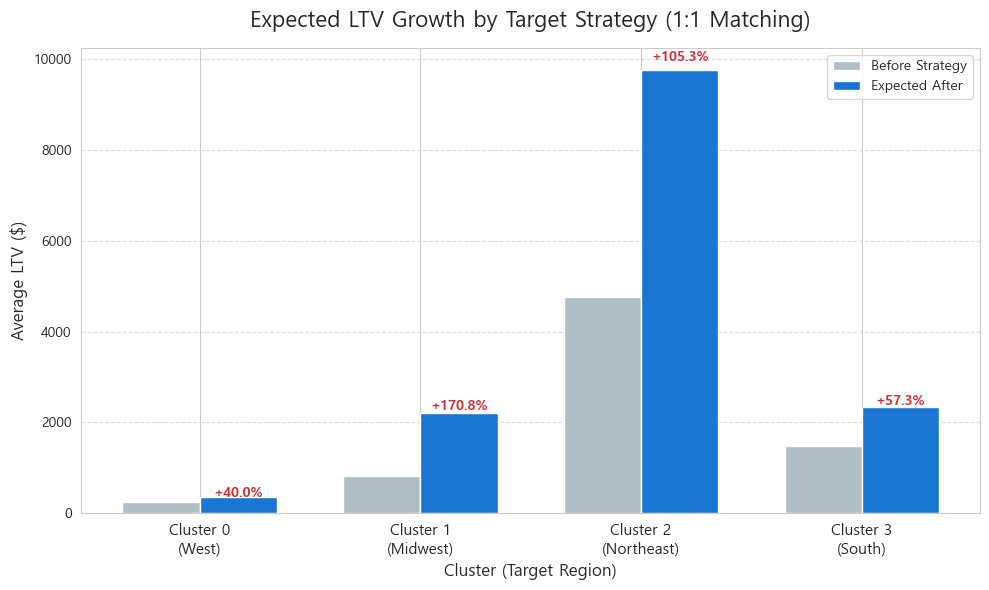

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 각 군집에 대응되는 타겟 지역 매핑 딕셔너리 (영문 데이터 기준)
# 0번: 서부(West), 1번: 중서부(Midwest), 2번: 동북부(Northeast), 3번: 남부(South)
target_mapping = {
    0: 'West',
    1: 'Midwest',
    2: 'Northeast',
    3: 'South'
}

# 2. 매핑 조건에 맞는 데이터만 필터링
# ltv_summary 데이터프레임에서 군집 번호에 맞는 타겟 지역 행만 남깁니다.
filtered_summary = ltv_summary[
    ltv_summary.apply(lambda x: target_mapping.get(x['CLUSTER_K4']) == x['REGION'], axis=1)
].reset_index(drop=True)

print("=== 타겟 지역 필터링 완료 요약 ===")
print(filtered_summary)

# 3. 결과 시각화 (X축 겹침 방지 적용)
plt.figure(figsize=(10, 6))
x = np.arange(len(filtered_summary))
width = 0.35

# 막대 그래프 생성
plt.bar(x - width/2, filtered_summary['AVG_LTV_BEFORE'], width, label='Before Strategy', color='#B0BEC5')
plt.bar(x + width/2, filtered_summary['AVG_LTV_AFTER'], width, label='Expected After', color='#1976D2')

# 그래프 타이틀 및 축 설정
plt.title('Expected LTV Growth by Target Strategy (1:1 Matching)', fontsize=16, pad=15)
plt.xlabel('Cluster (Target Region)', fontsize=12)
plt.ylabel('Average LTV ($)', fontsize=12)

# [핵심] X축 글자 겹침 해결: 라벨에 줄바꿈(\n)을 넣고 폰트 크기를 조정
x_labels = [f"Cluster {row['CLUSTER_K4']}\n({row['REGION']})" for _, row in filtered_summary.iterrows()]
plt.xticks(x, x_labels, fontsize=11, rotation=0) 

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 증가율(%) 텍스트 표시
for i, row in filtered_summary.iterrows():
    plt.text(i + width/2, row['AVG_LTV_AFTER'] + (row['AVG_LTV_AFTER'] * 0.02), 
             f"+{row['GROWTH_RATE(%)']:.1f}%", ha='center', fontweight='bold', color='#D32F2F')

# 여백 자동 조정 (라벨이 잘리지 않도록 함)
plt.tight_layout()
plt.show()

# 과감한 기대효과

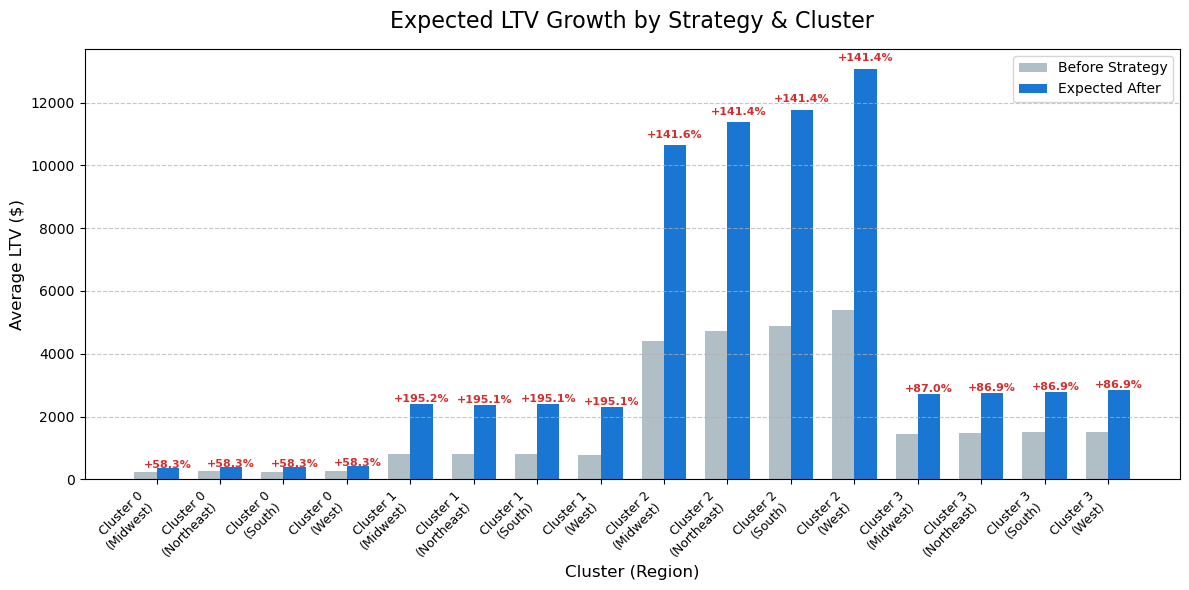

In [ ]:
# ---------------------------------------------------------
# 3. 결과 시각화 (Before & After 막대 그래프)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6)) # 항목이 16개이므로 가로 길이를 10에서 12로 살짝 늘림
x = np.arange(len(ltv_summary['REGION']))
width = 0.35

plt.bar(x - width/2, ltv_summary['AVG_LTV_BEFORE'], width, label='Before Strategy', color='#B0BEC5')
plt.bar(x + width/2, ltv_summary['AVG_LTV_AFTER'], width, label='Expected After', color='#1976D2')

plt.title('Expected LTV Growth by Strategy & Cluster', fontsize=16, pad=15)
plt.xlabel('Cluster (Region)', fontsize=12)
plt.ylabel('Average LTV ($)', fontsize=12)

# 줄바꿈(\n) 적용, 폰트 크기 축소, 45도 회전 및 텍스트 우측 정렬
x_labels = [f"Cluster {row['CLUSTER_K4']}\n({row['REGION']})" for _, row in ltv_summary.iterrows()]
plt.xticks(x, x_labels, fontsize=9, rotation=45, ha='right')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 증가율(%) 텍스트 표시 (글자가 겹치지 않도록 폰트 크기를 8로 조정)
for i, row in ltv_summary.iterrows():
    plt.text(i + width/2, row['AVG_LTV_AFTER'] + (row['AVG_LTV_AFTER']*0.02), 
             f"+{row['GROWTH_RATE(%)']:.1f}%", ha='center', fontsize=8, fontweight='bold', color='#D32F2F')

# 레이블이 화면 밖으로 잘리지 않도록 여백 자동 조정
plt.tight_layout()
plt.show()